# EDA — bureau_balance.csv

## Step 1 — Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
print("Libraries loaded")

Libraries loaded


## Step 2 — Load Data

In [6]:
df = pd.read_csv("data/application_train.csv")
df.columns = df.columns.str.lower().str.strip()
if "target" in df.columns:
    df = df.rename(columns={"target": "default"})

bureau = pd.read_csv("data/bureau.csv")
bureau.columns = bureau.columns.str.lower().str.strip()

bb = pd.read_csv("data/bureau_balance.csv")
bb.columns = bb.columns.str.lower().str.strip()

print("application_train shape:", df.shape)
print("bureau shape           :", bureau.shape)
print("bureau_balance shape   :", bb.shape)

application_train shape: (307511, 122)
bureau shape           : (1716428, 17)
bureau_balance shape   : (27299925, 3)


## Step 3

In [8]:
bb.head(15)

,sk_id_bureau,months_balance,status
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C
5,5715448,-5,C
6,5715448,-6,C
7,5715448,-7,C
8,5715448,-8,C
9,5715448,-9,0


In [9]:
print("=== COLUMNS ===")
print(bb.columns.tolist())
print()
print("=== DATA TYPES ===")
print(bb.dtypes.value_counts())

=== COLUMNS ===
['sk_id_bureau', 'months_balance', 'status']

=== DATA TYPES ===
int64     2
object    1
Name: count, dtype: int64


## Step 4 — Basic Statistics

In [11]:
bb.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
sk_id_bureau,27299925.0,6036297.33,492348.86,5001709.0,5730933.0,6070821.0,6431951.0,6842888.0
months_balance,27299925.0,-30.74,23.86,-96.0,-46.0,-25.0,-11.0,0.0


## Step 5 — Missing Values

In [13]:
missing_bb = (bb.isnull().sum() / len(bb) * 100).round(2)

print("=== MISSING VALUES ===")
if missing_bb[missing_bb > 0].empty:
    print("No missing values found")
else:
    print(missing_bb[missing_bb > 0])

=== MISSING VALUES ===
No missing values found


## Step 6 — Records Per Bureau Credit

=== MONTHS PER BUREAU CREDIT ===
count    817395.00
mean         33.40
std          25.79
min           1.00
25%          13.00
50%          26.00
75%          48.00
max          97.00
Name: months_balance, dtype: float64


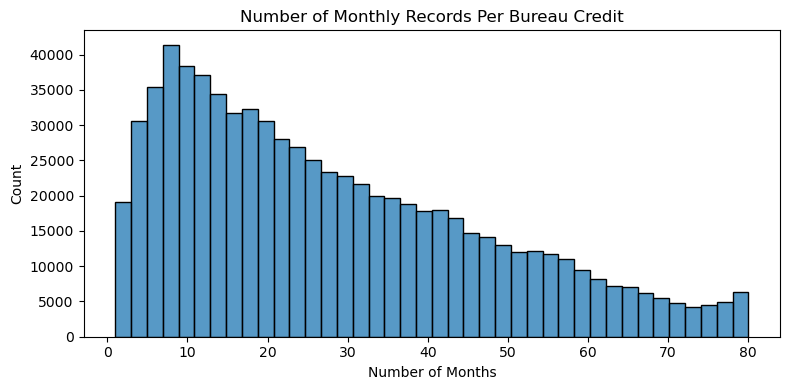

In [15]:
months_per_credit = bb.groupby("sk_id_bureau")["months_balance"].count()

print("=== MONTHS PER BUREAU CREDIT ===")
print(months_per_credit.describe().round(2))

plt.figure(figsize=(8, 4))
sns.histplot(months_per_credit[months_per_credit <= 80], bins=40)
plt.title("Number of Monthly Records Per Bureau Credit")
plt.xlabel("Number of Months")
plt.tight_layout()
plt.show()

## Step 7 — Distribution of Status Column

In [17]:
print("=== STATUS CODE MEANINGS ===")
print("C  = Closed")
print("0  = No days past due")
print("X  = Unknown")
print("1  = 1 to 29 days past due")
print("2  = 30 to 59 days past due")
print("3  = 60 to 89 days past due")
print("4  = 90 to 119 days past due")
print("5  = 120 or more days past due")
print()
print("=== STATUS VALUE COUNTS ===")
print(bb["status"].value_counts())
print()
print((bb["status"].value_counts(normalize=True) * 100).round(2))

=== STATUS CODE MEANINGS ===
C  = Closed
0  = No days past due
X  = Unknown
1  = 1 to 29 days past due
2  = 30 to 59 days past due
3  = 60 to 89 days past due
4  = 90 to 119 days past due
5  = 120 or more days past due

=== STATUS VALUE COUNTS ===
status
C    13646993
0     7499507
X     5810482
1      242347
5       62406
2       23419
3        8924
4        5847
Name: count, dtype: int64

status
C    49.99
0    27.47
X    21.28
1     0.89
5     0.23
2     0.09
3     0.03
4     0.02
Name: proportion, dtype: float64


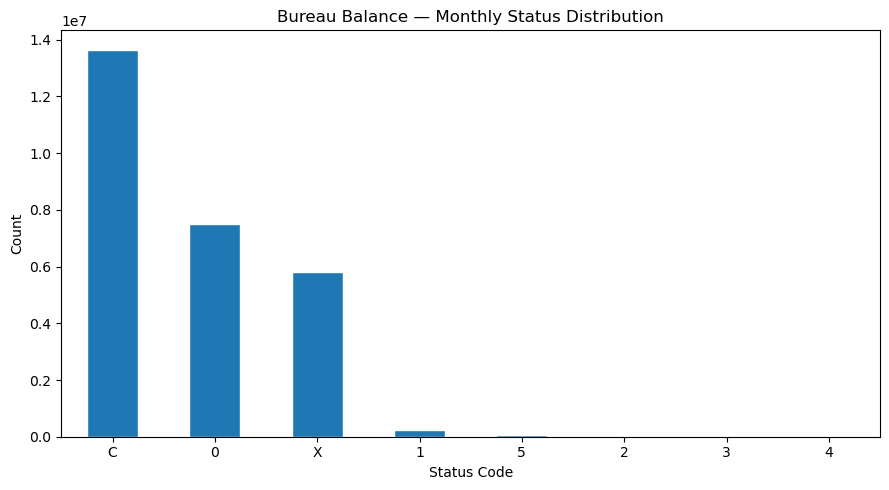

In [18]:
plt.figure(figsize=(9, 5))
bb["status"].value_counts().plot(kind="bar", edgecolor="white")
plt.title("Bureau Balance — Monthly Status Distribution")
plt.xlabel("Status Code")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
dpd_statuses = ["1", "2", "3", "4", "5"]
dpd_records  = bb[bb["status"].isin(dpd_statuses)]

print("Records with any DPD:",
      len(dpd_records),
      f"({round(len(dpd_records) / len(bb) * 100, 2)}%)")
print()
print("=== DPD BREAKDOWN ===")
print(dpd_records["status"].value_counts().sort_index())

Records with any DPD: 342943 (1.26%)

=== DPD BREAKDOWN ===
status
1    242347
2     23419
3      8924
4      5847
5     62406
Name: count, dtype: int64


=== MONTHS BALANCE ===
0   = current month
-96 = 8 years ago

count    27299925.00
mean          -30.74
std            23.86
min           -96.00
25%           -46.00
50%           -25.00
75%           -11.00
max             0.00
Name: months_balance, dtype: float64


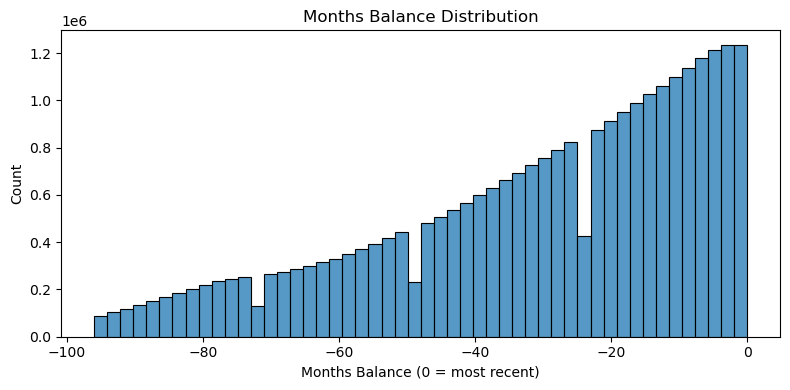

In [20]:
print("=== MONTHS BALANCE ===")
print("0   = current month")
print("-96 = 8 years ago")
print()
print(bb["months_balance"].describe().round(2))

plt.figure(figsize=(8, 4))
sns.histplot(bb["months_balance"], bins=50)
plt.title("Months Balance Distribution")
plt.xlabel("Months Balance (0 = most recent)")
plt.tight_layout()
plt.show()

## Step 8 — Coverage Analysis

In [22]:
bureau_ids_with_bb = set(bb["sk_id_bureau"])
bureau_ids_total   = set(bureau["sk_id_bureau"])

matched_credits = len(bureau_ids_with_bb & bureau_ids_total)

print("Total bureau credits                 :", len(bureau_ids_total))
print("Credits WITH monthly balance history :", matched_credits,
      f"({round(matched_credits / len(bureau_ids_total) * 100, 2)}%)")

bureau_with_bb     = bureau[bureau["sk_id_bureau"].isin(bureau_ids_with_bb)]
applicants_covered = bureau_with_bb["sk_id_curr"].nunique()

print()
print("Main applicants covered via bureau   :", applicants_covered,
      f"({round(applicants_covered / len(df) * 100, 2)}%)")

Total bureau credits                 : 1716428
Credits WITH monthly balance history : 774354 (45.11%)

Main applicants covered via bureau   : 134542 (43.75%)


## Step 9 — Why Two Level Aggregation is Needed

In [24]:
print("=== HOW BUREAU BALANCE CONNECTS TO MAIN DATASET ===")
print()
print("bureau_balance level: CREDIT x MONTH")
print("  - one row per month per credit")
print("  - linked by sk_id_bureau")
print()
print("bureau level: CREDIT")
print("  - one row per credit")
print("  - linked by sk_id_curr to main dataset")
print()
print("application_train level: APPLICANT")
print("  - one row per applicant")
print()
print("To use bureau_balance in the model:")
print("  Step 1: group bureau_balance by sk_id_bureau")
print("          get one row per credit")
print("  Step 2: merge with bureau to get sk_id_curr")
print("  Step 3: group by sk_id_curr")
print("          get one row per applicant")

=== HOW BUREAU BALANCE CONNECTS TO MAIN DATASET ===

bureau_balance level: CREDIT x MONTH
  - one row per month per credit
  - linked by sk_id_bureau

bureau level: CREDIT
  - one row per credit
  - linked by sk_id_curr to main dataset

application_train level: APPLICANT
  - one row per applicant

To use bureau_balance in the model:
  Step 1: group bureau_balance by sk_id_bureau
          get one row per credit
  Step 2: merge with bureau to get sk_id_curr
  Step 3: group by sk_id_curr
          get one row per applicant


In [25]:
sample_agg = (
    bb.head(500000)
    .groupby("sk_id_bureau")
    .agg(
        months_count   = ("months_balance", "count"),
        dpd_count      = ("status",
                          lambda x: x.isin(["1","2","3","4","5"]).sum()),
        dpd_rate       = ("status",
                          lambda x: x.isin(["1","2","3","4","5"]).sum() / len(x)),
        closed_months  = ("status",
                          lambda x: (x == "C").sum()),
        current_months = ("status",
                          lambda x: (x == "0").sum()),
    )
    .reset_index()
)

print("Shape after level 1 aggregation:", sample_agg.shape)
print()
print(sample_agg.head())

Shape after level 1 aggregation: (14829, 6)

   sk_id_bureau  months_count  dpd_count  dpd_rate  closed_months  \
0       5001726            39          0       0.0             33   
1       5001728             1          0       0.0              0   
2       5001729             7          0       0.0              1   
3       5001730            61          0       0.0             56   
4       5001778            36          0       0.0              0   

   current_months  
0               6  
1               1  
2               6  
3               5  
4               0  


## Step 10 — Sample Credit History

In [27]:
credits_with_dpd = bb[
    bb["status"].isin(["1", "2", "3"])
]["sk_id_bureau"].unique()[:3]

print("=== SAMPLE CREDIT HISTORIES ===")
print()
for credit_id in credits_with_dpd:
    history = (
        bb[bb["sk_id_bureau"] == credit_id]
        .sort_values("months_balance", ascending=False)
    )
    print(f"Credit ID: {credit_id}")
    print(history[["months_balance", "status"]].to_string(index=False))
    print()

=== SAMPLE CREDIT HISTORIES ===

Credit ID: 5715793
 months_balance status
            -20      X
            -21      0
            -22      0
            -23      0
            -24      0
            -25      0
            -26      0
            -27      0
            -28      0
            -29      0
            -30      0
            -31      0
            -32      0
            -33      0
            -34      0
            -35      0
            -36      0
            -37      0
            -38      0
            -39      1
            -40      1
            -41      0
            -42      0
            -43      1
            -44      0
            -45      0
            -46      0
            -47      0

Credit ID: 5715795
 months_balance status
            -11      X
            -12      0
            -13      0
            -14      0
            -15      0
            -16      0
            -17      0
            -18      0
            -19      0
            -20      0
        

## Observations

- 27,299,925 records, 3 columns only (sk_id_bureau, months_balance, status).
- No missing values — cleanest dataset in the entire collection.
- Average 33.4 months of history per credit (almost 3 years).
- History goes back up to 96 months which is 8 years.
- Status C (closed) accounts for 49.99% of records.
- Status 0 (current, no overdue) accounts for 27.47%.
- Only 1.26% of records show any days past due.
- IMPORTANT: bureau_balance only covers 43.75% of main dataset applicants
  via 2-level aggregation (months → bureau credit → applicant).
  This is lower than bureau.csv itself (85.69%) because not all bureau credits
  have monthly balance history recorded.
- Requires 2-level aggregation — cannot merge directly to applicant level.
- Must first aggregate to bureau credit level, then to applicant level via bureau.csv.
- bb_avg_dpd_rate shows correlation of +0.060 with default — useful signal.
- Decision: include with caution, noting the lower coverage.